# 01 — EDA

| Q | Question | Relevant |
|---|---|---|
| Q1 | Are the splits sound? | metric choice, leakage guarantee |
| Q2 | How long is the text? | LLM token budget |
| Q3 | Do classes separate lexically? | why neutral is hard |
| Q4 | How skewed is the prior? | prompt design, trivial floor |

**Scope:** 
- Exploration happens on `train_pool`
- `dev` is opened only for few-shot example selection
- `eval_natural` and `eval_balanced` are touched only for the token-budget calculation — a cost question, not a modelling one. Looking at eval to shape decisions is test-set contamination.
    - `eval_natural` --> what does this system do in production?
    - `eval_balanced` --> can the model tell neutral apart?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from src.config import DATA_PROCESSED, LABELS

pd.set_option("display.max_colwidth", 140)

splits = {
    name: pd.read_csv(DATA_PROCESSED / f"{name}.csv")
    for name in ["train_pool", "dev", "eval_natural", "eval_balanced"]
}
train = splits["train_pool"]

for name, df in splits.items():
    print(f"{name:15s} n={len(df):>6,}")
train.head(3)

train_pool      n=30,000
dev             n=   200
eval_natural    n= 1,000
eval_balanced   n=   300


,text,label
0,Good product. I use it everyday with my coffee. Use a shot of it in a 10 cup coffee pot. I buy this product via the subscribe service - ...,positive
1,"Very tasty, and as has already been said, as close to actually being hull-less as you'll find. It has a distinctive flavor, very nice. T...",positive
2,"Love the flavor. It is gluten, dairy and soy free. Dates, peanuts and salt. Can it be any simpler? Great Hunger satisfier and pick me up.",positive


## Q1 — Are the splits sound?

**Class balance and data leakage**

- Data investigate found that ~18% of sampled rows were duplicates — the same review copied across product size/pack variants. Left in, the same text lands in both `train_pool` and `eval`, the baseline collects an F1  it did not earn, and the whole LLM-vs-classical comparison is void.

In [2]:
names = list(splits)
for i, a in enumerate(names):
    for b in names[i + 1:]:
        overlap = set(splits[a]["text"]) & set(splits[b]["text"])
        assert not overlap, f"LEAKAGE {a}/{b}: {len(overlap)} shared texts"
print(f"OK — no leakage ({len(names) * (len(names) - 1) // 2} pairs checked)")

OK — no leakage (6 pairs checked)


In [3]:
dist = pd.DataFrame({
    name: df["label"].value_counts(normalize=True).mul(100).round(1)
    for name, df in splits.items()
}).reindex(LABELS)
display(dist)

,train_pool,dev,eval_natural,eval_balanced
label,,,,
negative,14.4,14.5,14.5,33.3
neutral,7.6,8.0,7.8,33.3
positive,78.0,77.5,77.7,33.3


In [4]:
counts = pd.DataFrame({name: df["label"].value_counts()
                       for name, df in splits.items()}).reindex(LABELS)
display(counts)

,train_pool,dev,eval_natural,eval_balanced
label,,,,
negative,4318,29,145,100
neutral,2284,16,78,100
positive,23398,155,777,100


## Q2 — Text length and token budget

Length drives LLM cost directly. It is also a potential leakage channel: if classes
differ sharply in length, a model can learn length instead of content.

In [5]:
for df in splits.values():
    df["n_chars"] = df["text"].str.len()

stats = (train.groupby("label")["n_chars"]
         .agg(median="median", mean="mean", std="std",
              skew=lambda s: s.skew(), p90=lambda s: s.quantile(0.90), max="max")
         .round(1)
         .reindex(LABELS))
display(stats)

ratio = stats.loc["neutral", "median"] / stats.loc[["negative", "positive"], "median"]
print("neutral median is longer by:",
      (ratio - 1).mul(100).round(1).to_dict(), "%")

,median,mean,std,skew,p90,max
label,,,,,,
negative,337.0,415.3,283.2,1.4,812.0,1500
neutral,363.0,455.6,314.5,1.2,914.4,1499
positive,278.0,364.7,267.8,1.6,744.0,1499


neutral median is longer by: {'negative': 7.7, 'positive': 30.6} %


In [6]:
# Cost estimate uses the EVAL sets — those are the texts the LLM will actually see.
# This is a budget question, not a modelling decision, so looking is legitimate.
CHARS_PER_TOKEN = 4          # rough for English
PROMPT_OVERHEAD = 70         # system prompt + JSON schema, tokens per call
OUTPUT_TOKENS = 40           # label + confidence + short reason

budget = []
for name in ["eval_natural", "eval_balanced", "dev"]:
    df = splits[name]
    tok = df["n_chars"] / CHARS_PER_TOKEN + PROMPT_OVERHEAD
    budget.append({"split": name, "n": len(df),
                   "tok_per_example": round(tok.mean()),
                   "tok_p90": round(tok.quantile(0.90)),
                   "input_tokens": int(tok.sum()),
                   "output_tokens": len(df) * OUTPUT_TOKENS})
budget = pd.DataFrame(budget)
display(budget)

,split,n,tok_per_example,tok_p90,input_tokens,output_tokens
0,eval_natural,1000,169,262,168909,40000
1,eval_balanced,300,176,278,52904,12000
2,dev,200,170,268,34014,8000


In [7]:
from src.config import PRICING

rows = []
for _, b in budget.iterrows():
    for model, (p_in, p_out) in PRICING.items():
        rows.append({"split": b["split"], "model": model,
                     "usd_per_run": round(b["input_tokens"] / 1e6 * p_in
                                          + b["output_tokens"] / 1e6 * p_out, 4)})
display(pd.DataFrame(rows).pivot(index="model", columns="split", values="usd_per_run"))
print("List prices. Groq runs are free-tier: actual spend is $0, "
      "but the table must report the production cost, not the promo.")

split,dev,eval_balanced,eval_natural
model,,,
claude-haiku-4-5-20251001,0.0740,0.1129,0.3689
openai/gpt-oss-120b,0.0099,0.0151,0.0493
openai/gpt-oss-20b,0.0050,0.0076,0.0247


List prices. Groq runs are free-tier: actual spend is $0, but the table must report the production cost, not the promo.


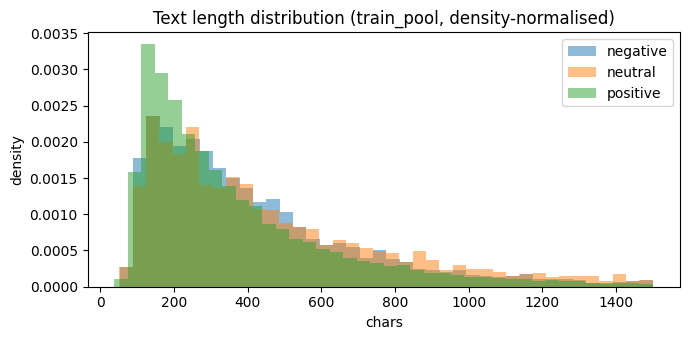

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for lbl in LABELS:
    ax.hist(train.loc[train["label"] == lbl, "n_chars"], bins=40,
            alpha=0.5, density=True, label=lbl)
ax.set_xlabel("chars")
ax.set_ylabel("density")
ax.set_title("Text length distribution (train_pool, density-normalised)")
ax.legend()
plt.tight_layout()
plt.show()

## Q3 — Do the classes separate lexically?

Two views, deliberately different questions:

- **Mean TF-IDF** → "which terms are prominent in this class?"
- **Log-odds** → "does this term *belong* to this class, or is it everywhere?"

**The stop-word decision**

The baseline uses `stop_words=None`, because sklearn's English list contains `not`,
`no`, `never`, `nothing` — removing negation from a sentiment task is destructive.
For readability the EDA uses that same list **minus** negation and contrast terms, so
what we inspect stays aligned with what the model sees.

In [9]:
TOP_N = 15
MIN_DF = 5           # 30k documents — a term in <5 docs is noise
MIN_TOTAL = 100      # scaled to corpus size (was 8 at 348 docs)

KEEP_WORDS = {"not", "no", "never", "nothing", "nobody", "none", "cannot",
              "but", "however", "though", "although", "very", "too", "only",
              "much", "more", "less", "least", "well"}
STOP = sorted(ENGLISH_STOP_WORDS - KEEP_WORDS)
print(f"stop list: {len(ENGLISH_STOP_WORDS)} → {len(STOP)}")
print("kept:", ", ".join(sorted(KEEP_WORDS & ENGLISH_STOP_WORDS)))

top_terms_tfidf, top_terms_logodds = {}, {}

stop list: 318 → 299
kept: although, but, cannot, however, least, less, more, much, never, no, nobody, none, not, nothing, only, though, too, very, well


In [10]:
vec = TfidfVectorizer(max_features=20_000, stop_words=STOP, min_df=MIN_DF)
X = vec.fit_transform(train["text"])
terms = np.array(vec.get_feature_names_out())

print("Mean TF-IDF\n")
for lbl in LABELS:
    scores = np.asarray(X[(train["label"] == lbl).values].mean(axis=0)).ravel()
    idx = scores.argsort()[-TOP_N:][::-1]
    top_terms_tfidf[lbl] = set(terms[idx])
    print(f"{lbl:9s}: {', '.join(terms[idx])}")

Mean TF-IDF

negative : not, but, like, product, taste, coffee, just, very, no, flavor, good, don, tea, buy, more
neutral  : but, not, like, taste, coffee, good, flavor, just, product, more, too, much, very, don, tea
positive : great, but, good, coffee, not, like, love, very, tea, product, taste, flavor, just, best, more


In [11]:
cv = CountVectorizer(max_features=20_000, stop_words=STOP, min_df=MIN_DF)
C = cv.fit_transform(train["text"])
vocab = np.array(cv.get_feature_names_out())

cls_counts = {l: np.asarray(C[(train["label"] == l).values].sum(axis=0)).ravel()
              for l in LABELS}
total_counts = sum(cls_counts.values())

# Rare terms make log-odds explode: a word appearing 3 times, all in one class, tops
# the ranking on coincidence. At 348 docs this filled the lists with product names
# (habanero, petite, steaks). A frequency floor removes that failure mode.
keep = total_counts >= MIN_TOTAL
print(f"vocabulary: {len(vocab):,} → {keep.sum():,} (total freq ≥ {MIN_TOTAL})\n")

logodds = {}
print("Log-odds\n")
for lbl in LABELS:
    a = cls_counts[lbl] + 1
    b = total_counts - cls_counts[lbl] + 1
    lo = np.log(a / a.sum()) - np.log(b / b.sum())
    logodds[lbl] = np.where(keep, lo, -np.inf)
    idx = logodds[lbl].argsort()[-TOP_N:][::-1]
    top_terms_logodds[lbl] = set(vocab[idx])
    print(f"{lbl:9s}: {', '.join(vocab[idx])}")

vocabulary: 9,501 → 1,511 (total freq ≥ 100)

Log-odds

negative : threw, refund, worst, return, awful, terrible, disappointment, waste, disappointing, horrible, poor, diarrhea, china, stale, nasty
neutral  : okay, ok, taco, average, rating, kinda, watery, weren, carbonated, shampoo, expecting, hoping, fudge, bland, berry
positive : hooked, yum, highly, bonus, beat, brownies, pleasantly, salads, perfect, town, addictive, skeptical, winner, delicious, wonderful


### A — How sharp is each class's signal?

Overlap counts ask "which words are shared". This asks "how distinctive are the top
words at all".

Caveat: the classes are now very unequal in size (~23k positive vs ~2.3k neutral) and
log-odds magnitudes are sensitive to class frequency. Read the ordering, not the
absolute values.

In [12]:
rows = []
for lbl in LABELS:
    top = np.sort(logodds[lbl])[-TOP_N:]
    rows.append({"class": lbl,
                 "top_mean": round(float(top.mean()), 3),
                 "top_max": round(float(top.max()), 3),
                 "n_docs": int((train["label"] == lbl).sum())})

strength = pd.DataFrame(rows).sort_values("top_mean", ascending=False)
display(strength)
print(f"Weakest lexical signal: {strength.iloc[-1]['class']}")

,class,top_mean,top_max,n_docs
0,negative,2.113,2.718,4318
2,positive,1.906,3.110,23398
1,neutral,1.145,1.795,2284


Weakest lexical signal: neutral


### B — How far apart are the class word distributions?

Jensen-Shannon uses the whole distribution rather than a top-N cut, so it is less
hostage to where we draw the list. Laplace smoothing is required — a zero probability
would otherwise let rare, class-exclusive terms dominate the distance.

In [13]:
from scipy.spatial.distance import jensenshannon

counts_f = {l: cls_counts[l][keep] for l in LABELS}
P = {l: (counts_f[l] + 1) / (counts_f[l] + 1).sum() for l in LABELS}

rows = [{"pair": f"{a} vs {b}",
         "js_distance": round(float(jensenshannon(P[a], P[b], base=2)), 4)}
        for a, b in [("negative", "positive"), ("neutral", "negative"),
                     ("neutral", "positive")]]
display(pd.DataFrame(rows).sort_values("js_distance", ascending=False))
print(f"Vocabulary: {keep.sum():,} terms. Higher = easier to separate.")

,pair,js_distance
0,negative vs positive,0.2281
2,neutral vs positive,0.1916
1,neutral vs negative,0.1699


Vocabulary: 1,511 terms. Higher = easier to separate.


## Q4 — How skewed is the prior, and what does it cost?

In [14]:
from sklearn.metrics import accuracy_score, f1_score

majority = train["label"].value_counts().idxmax()
print(f"majority class in train_pool: {majority}\n")

rows = []
for name in ["eval_natural", "eval_balanced"]:
    y = splits[name]["label"]
    pred = [majority] * len(y)
    rows.append({"eval_set": name, "n": len(y),
                 "accuracy": round(accuracy_score(y, pred), 4),
                 "macro_f1": round(f1_score(y, pred, labels=LABELS,
                                            average="macro", zero_division=0), 4)})
display(pd.DataFrame(rows))
print("Same model, no learning. Accuracy flatters it; macro-F1 does not.")

majority class in train_pool: positive



,eval_set,n,accuracy,macro_f1
0,eval_natural,1000,0.7770,0.2915
1,eval_balanced,300,0.3333,0.1667


Same model, no learning. Accuracy flatters it; macro-F1 does not.
